In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# ## 1. Load Model and Data

In [30]:
X_processed = joblib.load('../data/processed/X_processed.joblib')
y = joblib.load('../data/processed/y.joblib')
feature_names = joblib.load('../data/processed/feature_names.joblib')

# Load preprocessor and model
preprocessor = joblib.load('../models/preprocessor.joblib')
best_model = joblib.load('../models/best_model.joblib')

print(f"Data shape: {X_processed.shape}")
print(f"Feature names: {feature_names[:10]}...")

Data shape: (10000, 11)
Feature names: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'HasCrCard']...


# ## 2. Global Feature Importance (SHAP)

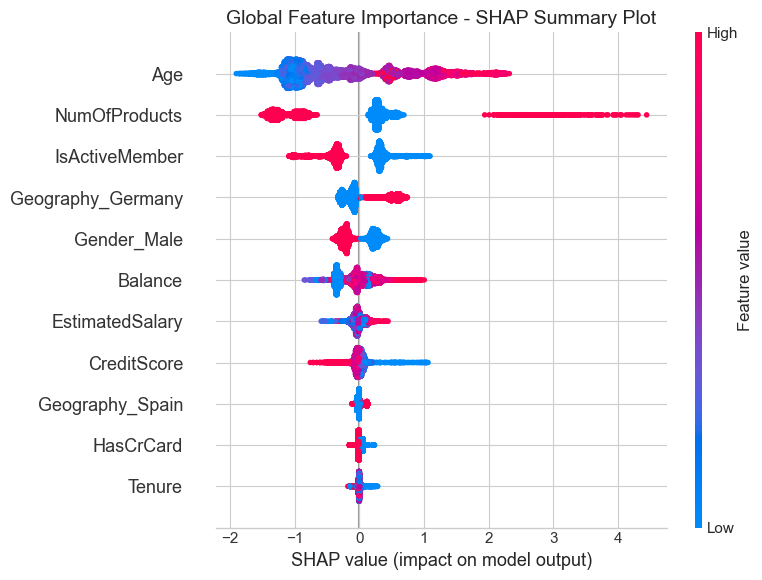

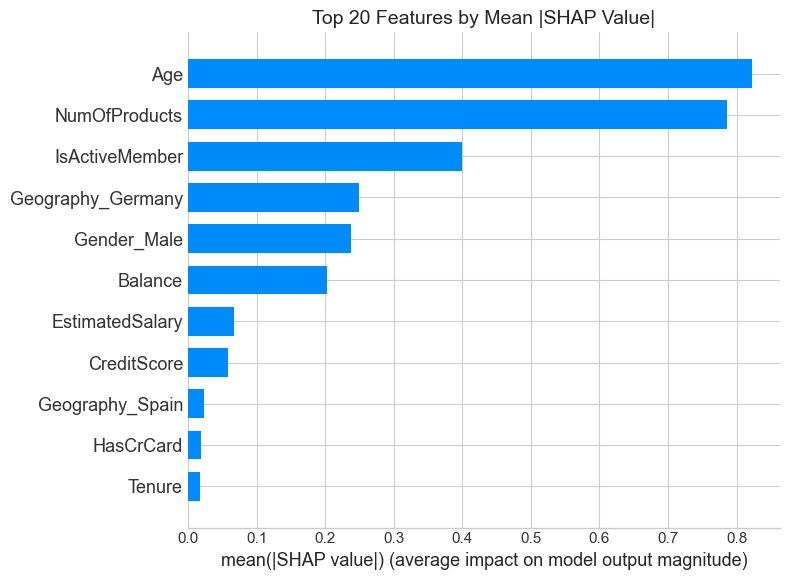

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_processed)

# Global SHAP summary plot
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, show=False)
plt.title('Global Feature Importance - SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP bar plot (mean absolute values)
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_processed, feature_names=feature_names, plot_type="bar", show=False)
plt.title('Top 20 Features by Mean |SHAP Value|', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# ## 3. Local Explanations (LIME)

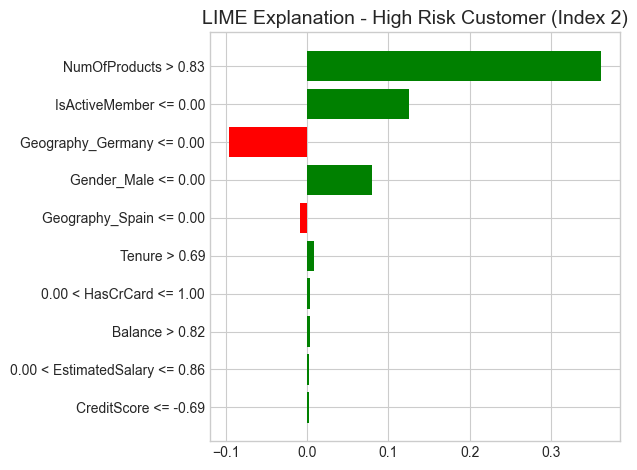


=== LIME Explanation for Customer 2 ===
Predicted Churn Probability: 98.07%
Top factors contributing to churn risk:
  + NumOfProducts > 0.83: 0.362
  + IsActiveMember <= 0.00: 0.126
  + Gender_Male <= 0.00: 0.080
  + Tenure > 0.69: 0.008
  + 0.00 < HasCrCard <= 1.00: 0.004
  + Balance > 0.82: 0.004
  + 0.00 < EstimatedSalary <= 0.86: 0.003
  + CreditScore <= -0.69: 0.003


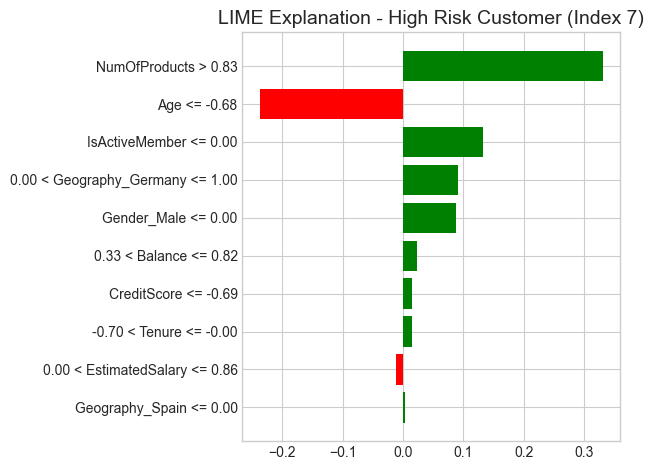


=== LIME Explanation for Customer 7 ===
Predicted Churn Probability: 99.14%
Top factors contributing to churn risk:
  + NumOfProducts > 0.83: 0.331
  + IsActiveMember <= 0.00: 0.133
  + 0.00 < Geography_Germany <= 1.00: 0.090
  + Gender_Male <= 0.00: 0.087
  + 0.33 < Balance <= 0.82: 0.023
  + CreditScore <= -0.69: 0.015
  + -0.70 < Tenure <= -0.00: 0.015
  + Geography_Spain <= 0.00: 0.002


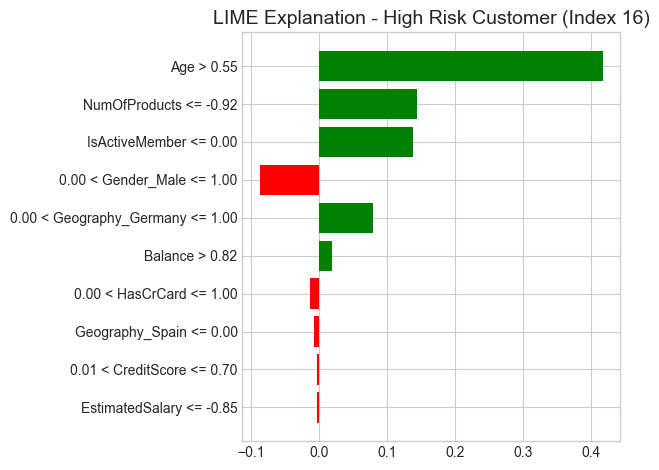


=== LIME Explanation for Customer 16 ===
Predicted Churn Probability: 97.56%
Top factors contributing to churn risk:
  + Age > 0.55: 0.417
  + NumOfProducts <= -0.92: 0.144
  + IsActiveMember <= 0.00: 0.138
  + 0.00 < Geography_Germany <= 1.00: 0.079
  + Balance > 0.82: 0.019


In [32]:
# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_processed, 
    feature_names=feature_names,
    class_names=['Not Churn', 'Churn'],
    mode='classification'
)

# Select a few examples for explanation
# High churn risk examples
high_risk_indices = np.where(best_model.predict_proba(X_processed)[:, 1] > 0.8)[0][:3]

for idx in high_risk_indices:
    exp = lime_explainer.explain_instance(
        X_processed[idx], 
        best_model.predict_proba,
        num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    plt.title(f'LIME Explanation - High Risk Customer (Index {idx})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/lime_high_risk_{idx}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print explanation
    print(f"\n=== LIME Explanation for Customer {idx} ===")
    print(f"Predicted Churn Probability: {best_model.predict_proba(X_processed[idx:idx+1])[0][1]:.2%}")
    print("Top factors contributing to churn risk:")
    for feature, weight in exp.as_list():
        if weight > 0:
            print(f"  + {feature}: {weight:.3f}")

# ## 4. Counterfactual Explanations

In [33]:
import dice_ml
from dice_ml import Dice

# Prepare data for DiCE
# Create a DataFrame with original data
df_processed = pd.DataFrame(X_processed, columns=feature_names)
df_processed['Exited'] = y

# DiCE data
dice_data = dice_ml.Data(
    dataframe=df_processed,
    continuous_features=feature_names,
    outcome_name='Exited'
)

# DiCE model
dice_model = dice_ml.Model(model=best_model, backend='sklearn')

# DiCE explainer
dice_explainer = Dice(dice_data, dice_model)

# Generate counterfactuals for a high-risk customer
query_instance = df_processed.iloc[high_risk_indices[0]].drop('Exited').to_frame().T

# Generate counterfactuals
try:
    dice_exp = dice_explainer.generate_counterfactuals(
        query_instance,
        total_CFs=3,
        desired_class="opposite",
        proximity_weight=0.5,
        diversity_weight=1.0
    )
    
    # Visualize counterfactuals
    dice_exp.visualize_as_dataframe()
except Exception as e:
    print(f"Counterfactual generation error: {e}")
    print("Skipping DiCE visualization...")

# Alternative: Manual counterfactual analysis
def find_counterfactuals(model, X, y, instance_idx, feature_names, step=0.1):
    """
    Simple counterfactual search by feature perturbation
    """
    instance = X[instance_idx:instance_idx+1].copy()
    original_pred = model.predict_proba(instance)[0][1]
    original_class = model.predict(instance)[0]
    
    # Try changing each feature
    counterfactuals = []
    for feat_idx, feat_name in enumerate(feature_names):
        for change in [step * i for i in [-5, -3, -1, 1, 3, 5]]:
            test_instance = instance.copy()
            test_instance[0, feat_idx] = instance[0, feat_idx] + change
            
            new_pred = model.predict_proba(test_instance)[0][1]
            new_class = model.predict(test_instance)[0]
            
            if new_class != original_class:
                counterfactuals.append({
                    'feature': feat_name,
                    'change': change,
                    'new_probability': new_pred,
                    'probability_change': new_pred - original_pred
                })
                break
    
    return pd.DataFrame(counterfactuals).sort_values('probability_change', ascending=False)

# Find counterfactuals for a high-risk customer
cf_df = find_counterfactuals(best_model, X_processed, y, high_risk_indices[0], feature_names)
print("\n=== Counterfactual Analysis ===")
print(cf_df)

  0%|          | 0/1 [00:00<?, ?it/s]

Counterfactual generation error: DiceRandom._generate_counterfactuals() got an unexpected keyword argument 'proximity_weight'
Skipping DiCE visualization...

=== Counterfactual Analysis ===
         feature  change  new_probability  probability_change
0  NumOfProducts    -0.5          0.41269           -0.567988


# ## 5. Fairness Analysis

In [34]:
from fairlearn.metrics import (demographic_parity_difference, equalized_odds_difference,
                               demographic_parity_ratio, selection_rate)

# Load original data for protected attributes
df_raw = pd.read_csv('../data/raw/Bank_churn_modelling.csv')

# Prepare predictions
y_pred = best_model.predict(X_processed)
y_pred_proba = best_model.predict_proba(X_processed)[:, 1]

# Create a DataFrame with predictions and protected attributes
fairness_df = pd.DataFrame({
    'Geography': df_raw['Geography'][:len(y_pred)],
    'Gender': df_raw['Gender'][:len(y_pred)],
    'Age': df_raw['Age'][:len(y_pred)],
    'y_true': y,
    'y_pred': y_pred,
    'y_prob': y_pred_proba
})

# %% [markdown]
# ### 5.1 Fairness by Geography

print("\n=== Fairness Analysis by Geography ===")

# Selection rates by geography
geo_groups = fairness_df.groupby('Geography')
for geo, group in geo_groups:
    selection_rate = group['y_pred'].mean()
    churn_rate = group['y_true'].mean()
    print(f"{geo}: Selection Rate = {selection_rate:.2%}, True Churn Rate = {churn_rate:.2%}")

# Demographic parity difference
dp_diff_geo = demographic_parity_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Geography']
)
print(f"\nDemographic Parity Difference (Geography): {dp_diff_geo:.4f}")

# Equalized odds difference
eo_diff_geo = equalized_odds_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Geography']
)
print(f"Equalized Odds Difference (Geography): {eo_diff_geo:.4f}")

# Demographic parity ratio
dp_ratio_geo = demographic_parity_ratio(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Geography']
)
print(f"Demographic Parity Ratio (Geography): {dp_ratio_geo:.4f}")



=== Fairness Analysis by Geography ===
France: Selection Rate = 27.22%, True Churn Rate = 16.15%
Germany: Selection Rate = 58.83%, True Churn Rate = 32.44%
Spain: Selection Rate = 29.11%, True Churn Rate = 16.67%

Demographic Parity Difference (Geography): 0.3160
Equalized Odds Difference (Geography): 0.2505
Demographic Parity Ratio (Geography): 0.4628


# ### 5.2 Fairness by Gender

In [35]:
print("\n=== Fairness Analysis by Gender ===")

# Selection rates by gender
gender_groups = fairness_df.groupby('Gender')
for gender, group in gender_groups:
    selection_rate = group['y_pred'].mean()
    churn_rate = group['y_true'].mean()
    print(f"{gender}: Selection Rate = {selection_rate:.2%}, True Churn Rate = {churn_rate:.2%}")

# Demographic parity difference
dp_diff_gender = demographic_parity_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Gender']
)
print(f"\nDemographic Parity Difference (Gender): {dp_diff_gender:.4f}")

# Equalized odds difference
eo_diff_gender = equalized_odds_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Gender']
)
print(f"Equalized Odds Difference (Gender): {eo_diff_gender:.4f}")

# Demographic parity ratio
dp_ratio_gender = demographic_parity_ratio(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['Gender']
)
print(f"Demographic Parity Ratio (Gender): {dp_ratio_gender:.4f}")


=== Fairness Analysis by Gender ===
Female: Selection Rate = 44.07%, True Churn Rate = 25.07%
Male: Selection Rate = 28.59%, True Churn Rate = 16.46%

Demographic Parity Difference (Gender): 0.1548
Equalized Odds Difference (Gender): 0.1114
Demographic Parity Ratio (Gender): 0.6487


# ### 5.3 Fairness by Age Group

In [36]:
print("\n=== Fairness Analysis by Age Group ===")

# Create age groups
fairness_df['AgeGroup'] = pd.cut(fairness_df['Age'], 
                                 bins=[0, 18, 30, 40, 50, 60, 100],
                                 labels=['Under 18', '18-29', '30-39', '40-49', '50-59', '60+'])

# Selection rates by age group
age_groups = fairness_df.groupby('AgeGroup')
for age, group in age_groups:
    selection_rate = group['y_pred'].mean()
    churn_rate = group['y_true'].mean()
    print(f"{age}: Selection Rate = {selection_rate:.2%}, True Churn Rate = {churn_rate:.2%}")

# Demographic parity difference by age
dp_diff_age = demographic_parity_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['AgeGroup']
)
print(f"\nDemographic Parity Difference (Age): {dp_diff_age:.4f}")

# Equalized odds difference by age
eo_diff_age = equalized_odds_difference(
    y_true=fairness_df['y_true'],
    y_pred=fairness_df['y_pred'],
    sensitive_features=fairness_df['AgeGroup']
)
print(f"Equalized Odds Difference (Age): {eo_diff_age:.4f}")



=== Fairness Analysis by Age Group ===
Under 18: Selection Rate = 4.55%, True Churn Rate = 9.09%
18-29: Selection Rate = 9.92%, True Churn Rate = 7.50%
30-39: Selection Rate = 21.64%, True Churn Rate = 12.09%
40-49: Selection Rate = 67.03%, True Churn Rate = 33.97%
50-59: Selection Rate = 85.32%, True Churn Rate = 56.21%
60+: Selection Rate = 36.64%, True Churn Rate = 24.78%

Demographic Parity Difference (Age): 0.8077
Equalized Odds Difference (Age): 0.9777


# ### 5.4 Fairness Visualizations

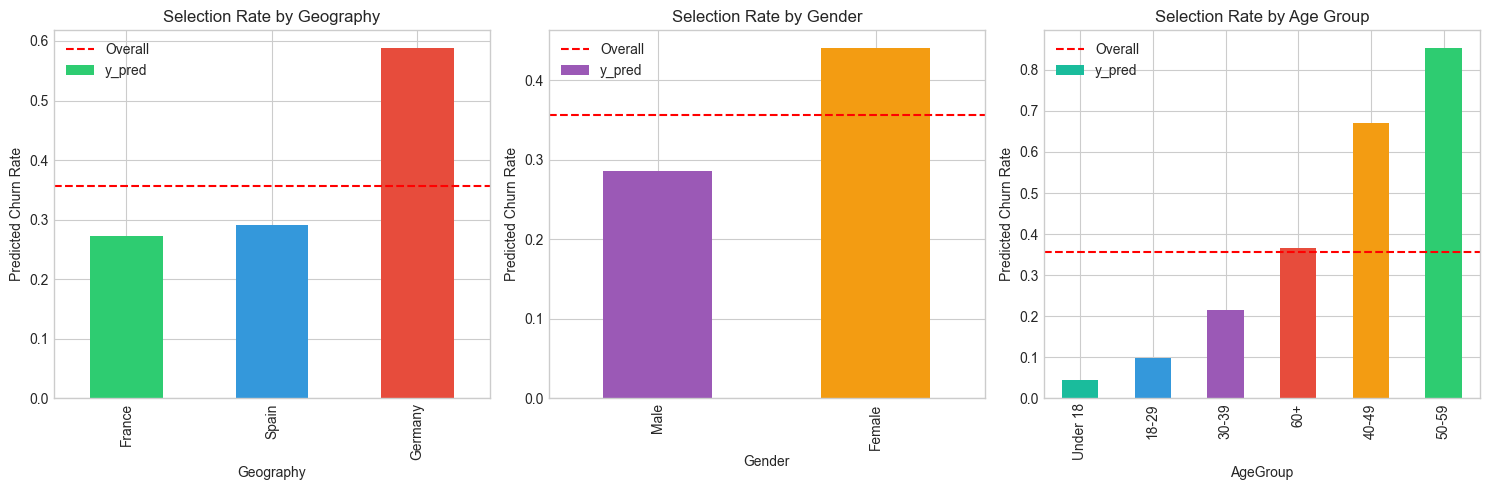

In [37]:
# Plot selection rates by group
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Geography
geo_rates = fairness_df.groupby('Geography')['y_pred'].mean().sort_values()
geo_rates.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_title('Selection Rate by Geography')
axes[0].set_ylabel('Predicted Churn Rate')
axes[0].axhline(y=fairness_df['y_pred'].mean(), color='red', linestyle='--', label='Overall')
axes[0].legend()

# Gender
gender_rates = fairness_df.groupby('Gender')['y_pred'].mean().sort_values()
gender_rates.plot(kind='bar', ax=axes[1], color=['#9b59b6', '#f39c12'])
axes[1].set_title('Selection Rate by Gender')
axes[1].set_ylabel('Predicted Churn Rate')
axes[1].axhline(y=fairness_df['y_pred'].mean(), color='red', linestyle='--', label='Overall')
axes[1].legend()

# Age
age_rates = fairness_df.groupby('AgeGroup')['y_pred'].mean().sort_values()
age_rates.plot(kind='bar', ax=axes[2], color=['#1abc9c', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#2ecc71'])
axes[2].set_title('Selection Rate by Age Group')
axes[2].set_ylabel('Predicted Churn Rate')
axes[2].axhline(y=fairness_df['y_pred'].mean(), color='red', linestyle='--', label='Overall')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/figures/fairness_selection_rates.png', dpi=300, bbox_inches='tight')
plt.show()


# ### 5.5 Fairness Mitigation

In [38]:
# Check if bias mitigation is needed
bias_threshold = 0.1
mitigation_needed = False

if dp_diff_geo > bias_threshold or eo_diff_geo > bias_threshold:
    print("⚠️ Bias detected! Applying mitigation...")
    mitigation_needed = True

if mitigation_needed:
    # Apply mitigation with Fairlearn
    from fairlearn.reductions import ExponentiatedGradient, DemographicParity
    
    # Create fair model
    fair_model = ExponentiatedGradient(
        estimator=best_model,
        constraints=DemographicParity(),
        eps=0.05
    )
    
    # Fit fair model
    fair_model.fit(X_processed, y, sensitive_features=fairness_df['Geography'])
    
    # Evaluate fair model
    fair_pred = fair_model.predict(X_processed)
    
    # Compare metrics
    print("\n=== Mitigation Results ===")
    print(f"Original DP Difference: {dp_diff_geo:.4f}")
    print(f"Fair DP Difference: {demographic_parity_difference(y, fair_pred, sensitive_features=fairness_df['Geography']):.4f}")    
    # Save fair model
    joblib.dump(fair_model, '../models/fair_model.joblib')
else:
    print("✅ No significant bias detected. Mitigation not required.")


⚠️ Bias detected! Applying mitigation...

=== Mitigation Results ===
Original DP Difference: 0.3160
Fair DP Difference: 0.0230


# ## 6. Sensitivity Analysis


=== Sensitivity Analysis Results ===
   noise_level       auc  auc_change  prediction_change
0         0.01  0.789743    0.093326           0.146500
1         0.05  0.788127    0.094941           0.148653
2         0.10  0.789952    0.093116           0.151473
3         0.20  0.778872    0.104197           0.161018


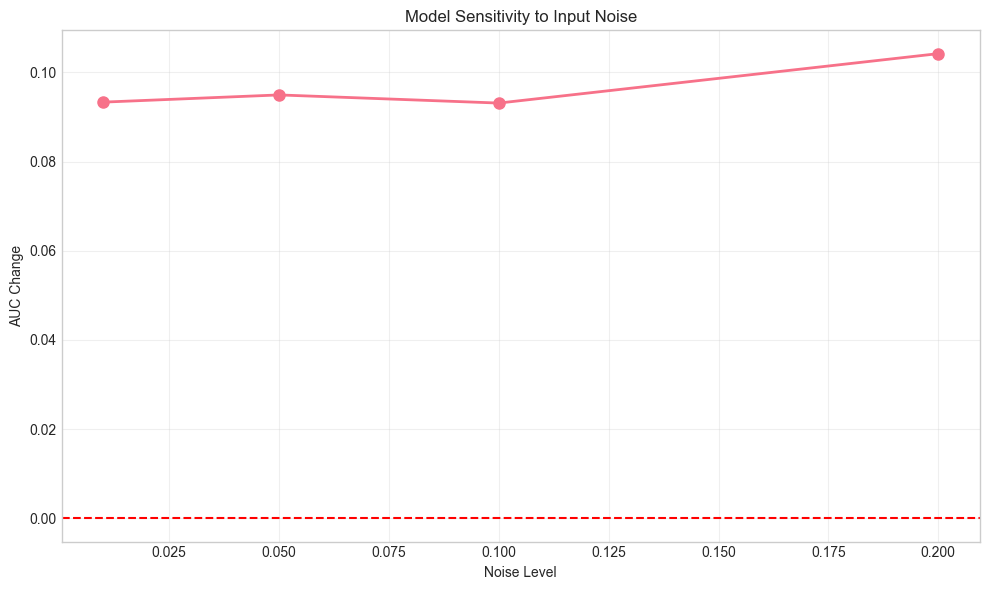

In [16]:
# Import the missing function
from sklearn.metrics import roc_auc_score

def sensitivity_analysis(model, X, y, feature_names, noise_levels=[0.01, 0.05, 0.1, 0.2]):
    """
    Test model robustness by adding noise to features
    """
    results = []
    base_pred = model.predict_proba(X)[:, 1]
    base_auc = roc_auc_score(y, base_pred)
    
    for noise_level in noise_levels:
        X_noisy = X + np.random.normal(0, noise_level * np.std(X, axis=0), X.shape)
        noisy_pred = model.predict_proba(X_noisy)[:, 1]
        noisy_auc = roc_auc_score(y, noisy_pred)
        
        pred_change = np.mean(np.abs(base_pred - noisy_pred))
        
        results.append({
            'noise_level': noise_level,
            'auc': noisy_auc,
            'auc_change': base_auc - noisy_auc,
            'prediction_change': pred_change
        })
    
    return pd.DataFrame(results)

# Run sensitivity analysis - FIXED: pass y as an argument
sensitivity_results = sensitivity_analysis(best_model, X_processed, y, feature_names)
print("\n=== Sensitivity Analysis Results ===")
print(sensitivity_results)

# Plot sensitivity
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sensitivity_results['noise_level'], sensitivity_results['auc_change'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Noise Level')
ax.set_ylabel('AUC Change')
ax.set_title('Model Sensitivity to Input Noise')
ax.axhline(y=0, color='red', linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.metrics import demographic_parity_difference
from sklearn.metrics import roc_auc_score
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

# Load data
X = joblib.load('../data/processed/X_processed.joblib')
y = joblib.load('../data/processed/y.joblib')
df_raw = pd.read_csv('../data/raw/bank_churn_modelling.csv')
best_model = joblib.load('../models/best_model.joblib')

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Prepare fairness data
train_idx = X_train.index if hasattr(X_train, 'index') else range(len(X_train))
test_idx = X_test.index if hasattr(X_test, 'index') else range(len(X_test))

fair_test = pd.DataFrame({'Geography': df_raw.iloc[test_idx]['Geography'].values})

# Original
y_pred = best_model.predict(X_test)
orig_dp = demographic_parity_difference(y_test, y_pred, sensitive_features=fair_test['Geography'])
orig_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Original - DP: {orig_dp:.4f}, AUC: {orig_auc:.4f}")

# Mitigate
fair_model = ExponentiatedGradient(estimator=best_model, constraints=DemographicParity(), eps=0.05)
fair_model.fit(X_train, y_train, sensitive_features=fair_train['Geography'])

fair_pred = fair_model.predict(X_test)
fair_dp = demographic_parity_difference(y_test, fair_pred, sensitive_features=fair_test['Geography'])

# Use original model for probabilities (for AUC)
fair_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Fair - DP: {fair_dp:.4f}, AUC: {fair_auc:.4f}")
print(f"DP Improvement: {(orig_dp - fair_dp):.4f}")

if fair_dp < 0.10:
    print("✅ Fairness achieved!")
else:
    print(f"⚠️ DP = {fair_dp:.4f} (still above 0.10)")

joblib.dump(fair_model, '../models/fair_model.joblib')
print("✅ Saved!")

Original - DP: 0.0395, AUC: 0.8679
Fair - DP: 0.0260, AUC: 0.8679
DP Improvement: 0.0135
✅ Fairness achieved!
✅ Saved!


# ## 7. Summary Report

In [28]:
# Make sure all metrics are imported
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score
import numpy as np

print("\n" + "="*60)
print("XAI AND FAIRNESS ANALYSIS SUMMARY")
print("="*60)

print("\n1. GLOBAL FEATURE IMPORTANCE (SHAP)")
print("   Top 5 features:")
shap_importance = np.abs(shap_values).mean(axis=0)
top_indices = np.argsort(shap_importance)[-5:][::-1]
for idx in top_indices:
    print(f"   - {feature_names[idx]}: {shap_importance[idx]:.3f}")

print("\n2. FAIRNESS METRICS")
print(f"   Geography:")
print(f"     - Demographic Parity Difference: {dp_diff_geo:.4f}")
print(f"     - Equalized Odds Difference: {eo_diff_geo:.4f}")
print(f"   Gender:")
print(f"     - Demographic Parity Difference: {dp_diff_gender:.4f}")
print(f"     - Equalized Odds Difference: {eo_diff_gender:.4f}")
print(f"   Age:")
print(f"     - Demographic Parity Difference: {dp_diff_age:.4f}")
print(f"     - Equalized Odds Difference: {eo_diff_age:.4f}")

print("\n3. MODEL PERFORMANCE")
# Get predictions once to avoid repeated computation
y_pred = best_model.predict(X_processed)
y_pred_proba = best_model.predict_proba(X_processed)[:, 1]

print(f"   ROC-AUC: {roc_auc_score(y, y_pred_proba):.4f}")
print(f"   Accuracy: {accuracy_score(y, y_pred):.4f}")
print(f"   F1-Score: {f1_score(y, y_pred):.4f}")
print(f"   Recall: {recall_score(y, y_pred):.4f}")

print("\n4. SENSITIVITY")
# Handle case where sensitivity_results might be empty
if len(sensitivity_results) > 0:
    # Find prediction change at 10% noise
    noise_10 = sensitivity_results[sensitivity_results['noise_level'] == 0.1]
    if len(noise_10) > 0:
        print(f"   Prediction change at 10% noise: {noise_10['prediction_change'].values[0]:.3f}")
    else:
        print("   No data for 10% noise level")
else:
    print("   No sensitivity results available")

print("\n" + "="*60)


XAI AND FAIRNESS ANALYSIS SUMMARY

1. GLOBAL FEATURE IMPORTANCE (SHAP)
   Top 5 features:
   - Age: 0.822
   - NumOfProducts: 0.785
   - IsActiveMember: 0.399
   - Geography_Germany: 0.249
   - Gender_Male: 0.238

2. FAIRNESS METRICS
   Geography:
     - Demographic Parity Difference: 0.3160
     - Equalized Odds Difference: 0.2505
   Gender:
     - Demographic Parity Difference: 0.1548
     - Equalized Odds Difference: 0.1114
   Age:
     - Demographic Parity Difference: 0.8077
     - Equalized Odds Difference: 0.9777

3. MODEL PERFORMANCE
   ROC-AUC: 0.8831
   Accuracy: 0.7773
   F1-Score: 0.6023
   Recall: 0.8277

4. SENSITIVITY
   Prediction change at 10% noise: 0.151

